In [2]:
# Load
import os
import numpy as np
from PIL import Image

train_path = "/Users/aomine/Desktop/Mnist/mnist_png/train/"

def load_mnist_images(path):
    X, y = [], []
    for label in sorted(os.listdir(path)):
        label_path = os.path.join(path, label)
        if not os.path.isdir(label_path):
            continue
        for file in sorted(os.listdir(label_path)):
            if file.startswith('.'):
                continue
            img = Image.open(os.path.join(label_path, file)).convert('L')
            img = img.resize((28, 28), Image.LANCZOS)
            X.append(np.array(img).flatten())
            y.append(int(label))
    return np.array(X, dtype='float32') / 255.0, np.array(y)

x_train, y_train = load_mnist_images(train_path)

print("Train shape:", x_train.shape)
print("Labels distribution:")
for i in range(10):
    print(f"  Digit {i}: {np.sum(y_train == i)} images")

Train shape: (60000, 784)
Labels distribution:
  Digit 0: 5923 images
  Digit 1: 6742 images
  Digit 2: 5958 images
  Digit 3: 6131 images
  Digit 4: 5842 images
  Digit 5: 5421 images
  Digit 6: 5918 images
  Digit 7: 6265 images
  Digit 8: 5851 images
  Digit 9: 5949 images


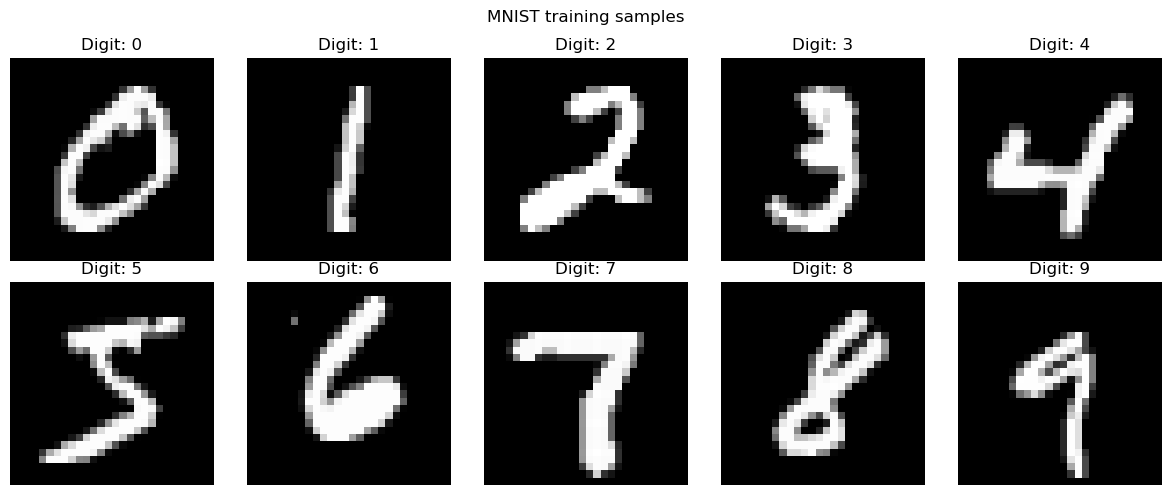

In [3]:
#some visual 
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    ax = axes[digit // 5][digit % 5]
    ax.imshow(x_train[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'Digit: {digit}')
    ax.axis('off')
plt.suptitle('MNIST training samples')
plt.tight_layout()
plt.show()

In [4]:
#train/Val
from sklearn.model_selection import train_test_split

x_train_sub, x_val, y_train_sub, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print("Training subset shape:", x_train_sub.shape)
print("Validation shape:     ", x_val.shape)

Training subset shape: (54000, 784)
Validation shape:      (6000, 784)


In [5]:
#KNN 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

knn = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
knn.fit(x_train_sub, y_train_sub)

y_val_pred_knn = knn.predict(x_val)
print(f"KNN Validation Accuracy: {accuracy_score(y_val, y_val_pred_knn):.4f}")
print(classification_report(y_val, y_val_pred_knn))

KNN Validation Accuracy: 0.9760
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       592
           1       0.97      1.00      0.98       674
           2       0.99      0.96      0.98       596
           3       0.97      0.97      0.97       613
           4       0.98      0.98      0.98       584
           5       0.97      0.97      0.97       542
           6       0.98      0.99      0.99       592
           7       0.97      0.97      0.97       627
           8       0.99      0.94      0.96       585
           9       0.96      0.97      0.97       595

    accuracy                           0.98      6000
   macro avg       0.98      0.98      0.98      6000
weighted avg       0.98      0.98      0.98      6000



In [6]:
#SVM
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=5, gamma='scale')
svm.fit(x_train_sub, y_train_sub)

y_val_pred_svm = svm.predict(x_val)
print(f"SVM Validation Accuracy: {accuracy_score(y_val, y_val_pred_svm):.4f}")
print(classification_report(y_val, y_val_pred_svm))

SVM Validation Accuracy: 0.9875
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       592
           1       0.99      1.00      0.99       674
           2       0.99      0.99      0.99       596
           3       0.99      0.99      0.99       613
           4       0.98      0.99      0.98       584
           5       0.98      0.98      0.98       542
           6       0.99      0.99      0.99       592
           7       0.99      0.99      0.99       627
           8       0.99      0.98      0.98       585
           9       0.98      0.98      0.98       595

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



In [7]:
# decision tree 
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(x_train_sub, y_train_sub)

y_val_pred_tree = dtree.predict(x_val)
print(f"Decision Tree Validation Accuracy: {accuracy_score(y_val, y_val_pred_tree):.4f}")
print(classification_report(y_val, y_val_pred_tree))

Decision Tree Validation Accuracy: 0.8728
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       592
           1       0.94      0.94      0.94       674
           2       0.85      0.83      0.84       596
           3       0.86      0.83      0.84       613
           4       0.86      0.89      0.88       584
           5       0.80      0.84      0.82       542
           6       0.90      0.90      0.90       592
           7       0.91      0.91      0.91       627
           8       0.83      0.81      0.82       585
           9       0.85      0.84      0.85       595

    accuracy                           0.87      6000
   macro avg       0.87      0.87      0.87      6000
weighted avg       0.87      0.87      0.87      6000



In [8]:
# logistic regression 
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(x_train_sub, y_train_sub)

y_val_pred_lr = lr.predict(x_val)
print(f"Logistic Regression Validation Accuracy: {accuracy_score(y_val, y_val_pred_lr):.4f}")
print(classification_report(y_val, y_val_pred_lr))

Logistic Regression Validation Accuracy: 0.9152
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       592
           1       0.94      0.97      0.96       674
           2       0.90      0.89      0.90       596
           3       0.90      0.86      0.88       613
           4       0.92      0.94      0.93       584
           5       0.87      0.86      0.86       542
           6       0.93      0.95      0.94       592
           7       0.93      0.94      0.93       627
           8       0.89      0.87      0.88       585
           9       0.91      0.91      0.91       595

    accuracy                           0.92      6000
   macro avg       0.91      0.91      0.91      6000
weighted avg       0.91      0.92      0.91      6000



In [9]:
# comparison on val set 
print("=" * 45)
print("  MODEL COMPARISON ON VALIDATION SET")
print("=" * 45)
results_val = {
    'KNN':                 accuracy_score(y_val, y_val_pred_knn),
    'SVM':                 accuracy_score(y_val, y_val_pred_svm),
    'Decision Tree':       accuracy_score(y_val, y_val_pred_tree),
    'Logistic Regression': accuracy_score(y_val, y_val_pred_lr),
}
for name, acc in sorted(results_val.items(), key=lambda x: -x[1]):
    print(f"  {name:<25} {acc:.4f}")
print("\n→ Best model: SVM — selected for final evaluation.")

  MODEL COMPARISON ON VALIDATION SET
  SVM                       0.9875
  KNN                       0.9760
  Logistic Regression       0.9152
  Decision Tree             0.8728

→ Best model: SVM — selected for final evaluation.


In [10]:
# mnist test set 10k 
test_path = "/Users/aomine/Desktop/Mnist/mnist_png/test/"
x_test_mnist, y_test_mnist = load_mnist_images(test_path)

print("MNIST Test shape:", x_test_mnist.shape)

y_pred_mnist_test = svm.predict(x_test_mnist)
print(f"\nSVM on MNIST test set: {accuracy_score(y_test_mnist, y_pred_mnist_test):.4f}")
print(classification_report(y_test_mnist, y_pred_mnist_test))

MNIST Test shape: (10000, 784)

SVM on MNIST test set: 0.9840
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.99      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [11]:
# preprocess hand drawn
import scipy.ndimage

def preprocess_drawing(img_path):
    img = Image.open(img_path).convert('RGBA')
    r, g, b, alpha = img.split()
    alpha_array = np.array(alpha, dtype='float32')
    img_array = alpha_array
    img_array[img_array < 30] = 0

    rows = np.any(img_array > 0, axis=1)
    cols = np.any(img_array > 0, axis=0)
    if not rows.any():
        return np.zeros(784, dtype='float32')

    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    h, w = img_array.shape
    pad_r = max(1, int((rmax - rmin) * 0.1))
    pad_c = max(1, int((cmax - cmin) * 0.1))
    rmin = max(0, rmin - pad_r)
    rmax = min(h - 1, rmax + pad_r)
    cmin = max(0, cmin - pad_c)
    cmax = min(w - 1, cmax + pad_c)
    cropped = img_array[rmin:rmax+1, cmin:cmax+1]

    digit_img = Image.fromarray(cropped.astype('uint8')).resize((20, 20), Image.LANCZOS)
    canvas = np.zeros((28, 28), dtype='float32')
    canvas[4:24, 4:24] = np.array(digit_img, dtype='float32')

    import scipy.ndimage
    cy, cx = scipy.ndimage.center_of_mass(canvas)
    shift_y = np.clip(int(round(14 - cy)), -6, 6)  
    shift_x = np.clip(int(round(14 - cx)), -6, 6) 
    canvas = scipy.ndimage.shift(canvas, [shift_y, shift_x], cval=0.0)

    return (canvas / 255.0).flatten()
def load_my_drawings(path):
    X, y = [], []
    for label in sorted(os.listdir(path)):
        label_path = os.path.join(path, label)
        if not os.path.isdir(label_path):
            continue
        try:
            digit = int(label)
        except ValueError:
            continue
        for file in sorted(os.listdir(label_path)):
            if file.startswith('.'):
                continue
            try:
                X.append(preprocess_drawing(os.path.join(label_path, file)))
                y.append(digit)
            except Exception as e:
                print(f"  Skipped {file}: {e}")
    return np.array(X, dtype='float32'), np.array(y)


new_data_path = "/Users/aomine/Desktop/MyDrawings/"
x_new, y_new = load_my_drawings(new_data_path)
print("Hand-drawn data shape:", x_new.shape)

Hand-drawn data shape: (200, 784)


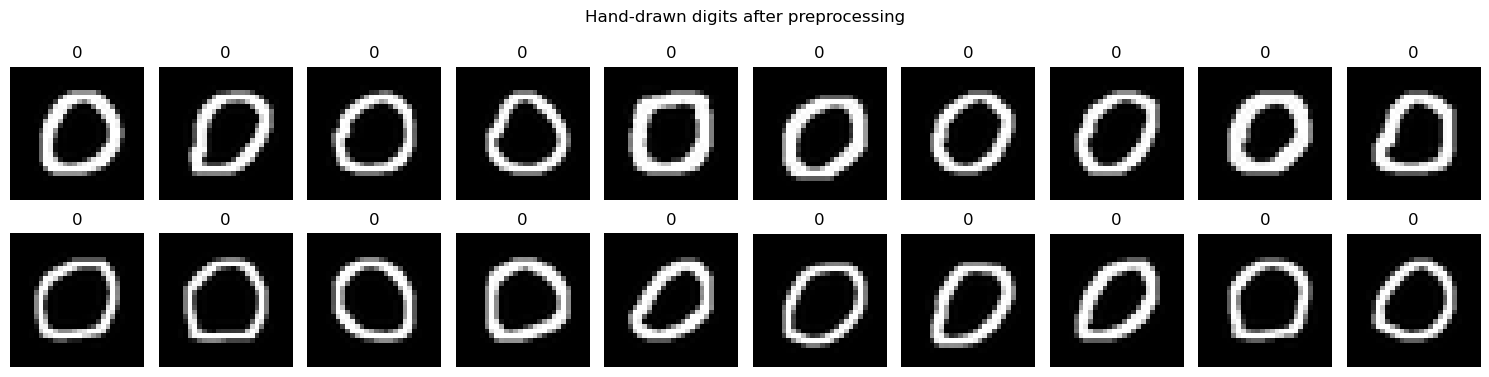

In [12]:
# Visual check: here i preprosessed my drawings, because i wrote them by black, on white. But mnist needed white digits on black
# background with white color
import matplotlib.pyplot as plt

n = min(len(x_new), 20)
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
axes = axes.flatten()
for i in range(n):
    axes[i].imshow(x_new[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'{y_new[i]}')
    axes[i].axis('off')
for i in range(n, len(axes)):
    axes[i].axis('off')
plt.suptitle('Hand-drawn digits after preprocessing')
plt.tight_layout()
plt.show()

In [13]:
# modles evaluation
from sklearn.metrics import accuracy_score, classification_report

models = {
    'KNN':                 knn,
    'SVM':                 svm,
    'Decision Tree':       dtree,
    'Logistic Regression': lr,
}

results_new = {}
for name, model in models.items():
    y_pred = model.predict(x_new)
    acc = accuracy_score(y_new, y_pred)
    results_new[name] = acc
    print(f"\n{'='*45}")
    print(f"{name} — Accuracy on hand-drawn: {acc:.4f}")
    print(classification_report(y_new, y_pred, zero_division=0))

print("\n" + "="*45)
print("  FINAL SUMMARY")
print("="*45)
print(f"  {'Model':<25} {'Validation':>10} {'Hand-drawn':>10}")
print("-"*45)
for name in models:
    print(f"  {name:<25} {results_val[name]:>10.4f} {results_new[name]:>10.4f}")


KNN — Accuracy on hand-drawn: 0.7900
              precision    recall  f1-score   support

           0       0.77      1.00      0.87        20
           1       0.83      0.25      0.38        20
           2       0.86      0.95      0.90        20
           3       0.61      0.95      0.75        20
           4       1.00      0.85      0.92        20
           5       0.81      0.85      0.83        20
           6       0.91      1.00      0.95        20
           7       0.63      0.95      0.76        20
           8       0.89      0.85      0.87        20
           9       0.83      0.25      0.38        20

    accuracy                           0.79       200
   macro avg       0.82      0.79      0.76       200
weighted avg       0.82      0.79      0.76       200


SVM — Accuracy on hand-drawn: 0.8550
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        20
           1       1.00      0.25      0.40        20
  

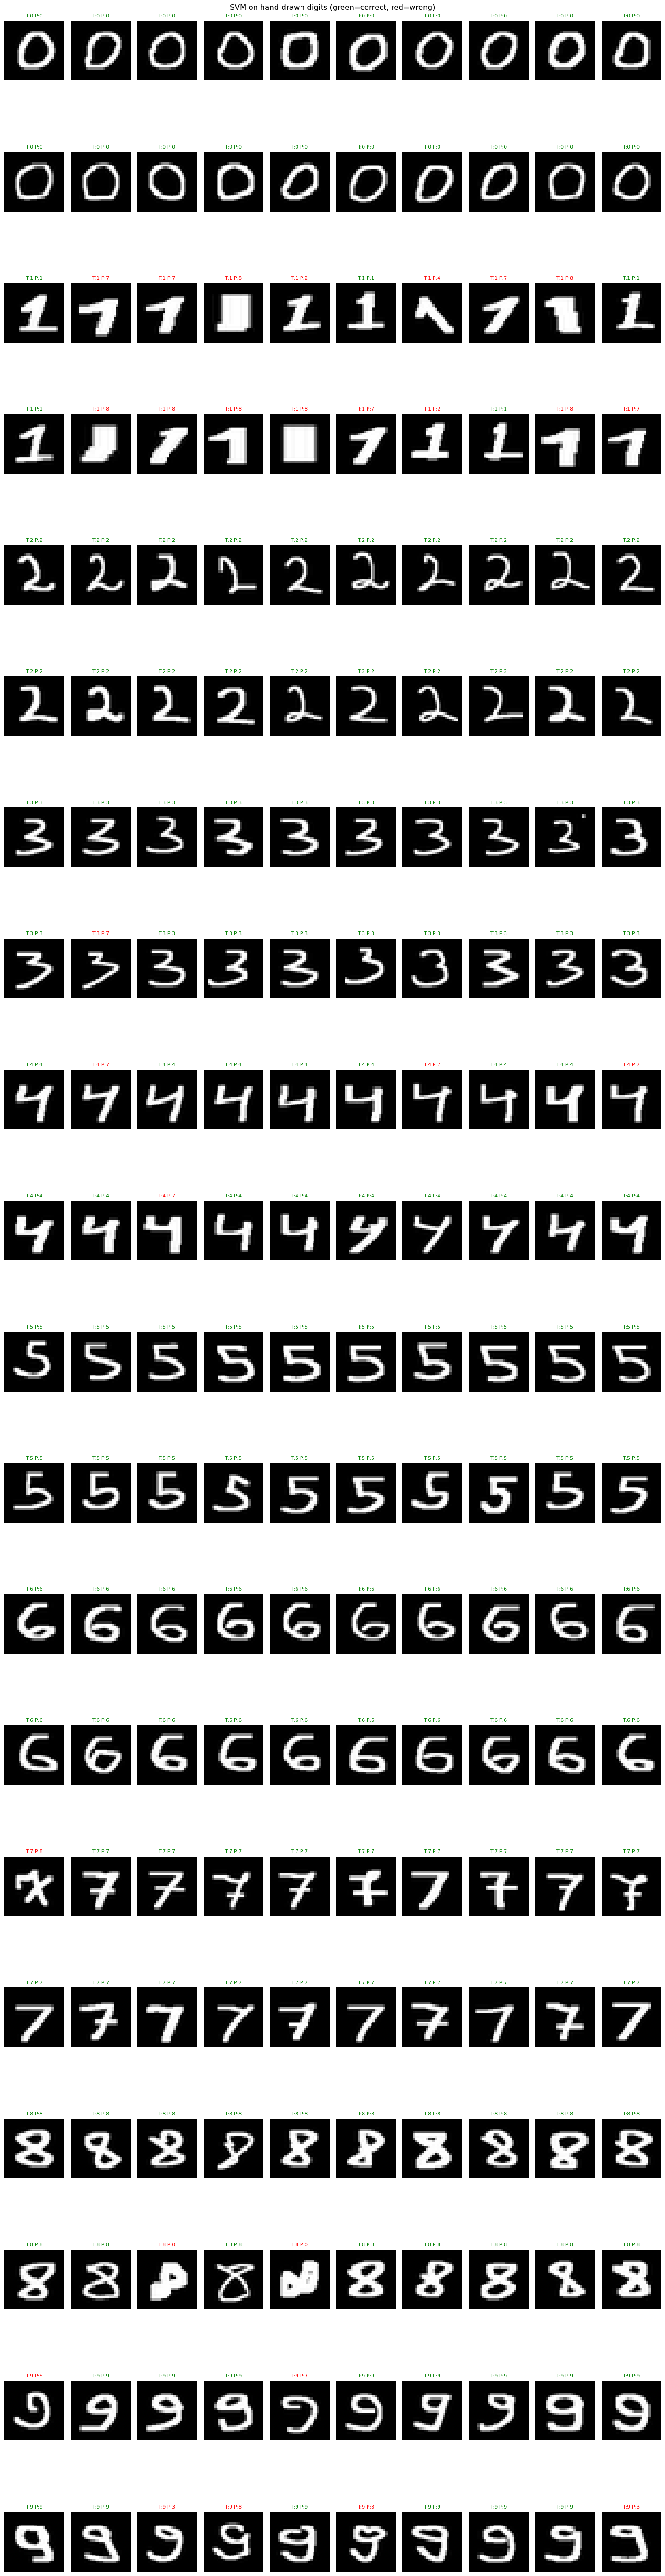

In [14]:
# SVM pred visual
import matplotlib.pyplot as plt

y_pred_svm_new = svm.predict(x_new)
n = len(x_new)
cols = 10
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = np.array(axes).flatten()
for i in range(n):
    axes[i].imshow(x_new[i].reshape(28, 28), cmap='gray')
    correct = y_pred_svm_new[i] == y_new[i]
    axes[i].set_title(f'T:{y_new[i]} P:{y_pred_svm_new[i]}',
                      color='green' if correct else 'red', fontsize=8)
    axes[i].axis('off')
for i in range(n, len(axes)):
    axes[i].axis('off')
plt.suptitle('SVM on hand-drawn digits (green=correct, red=wrong)')
plt.tight_layout()
plt.show()